# 💓 Laboratorio 02.1: Pronóstico Fisiológico de Frecuencia Cardíaca
### Reposo (Basal "Normal"), Carrera (Running), Gimnasio (Fuerza) y Caminata (Walking)

---

## 🎯 Objetivo
Pronosticar el espectro cardiovascular completo del atleta con restricciones fisiológicas y filtrado de anomalías:
1. **Frecuencia Cardíaca en Reposo (`resting_heart_rate`)**: Umbral clínico de seguridad ($\ge 38$ bpm).
2. **Frecuencia Cardíaca en Carrera (`running_avg_hr`)**: Esfuerzo aeróbico/anaeróbico acotado en $[110, 200]$ bpm.
3. **Frecuencia Cardíaca en Gimnasio / Fuerza (`gym_avg_hr`)**: Sesiones neuromusculares acotadas en $[80, 175]$ bpm.
4. **Frecuencia Cardíaca en Caminata (`walking_avg_hr`)**: Actividad ligera acotada en $[75, 150]$ bpm.


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    GarminProphetForecaster,
    HoltWintersForecaster,
    EnsembleBiometricForecaster,
)
from src.analytics.predictions_manager import BiometricPredictionsManager

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Carga de datos limpios DVC
dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

print(f"📊 Dataset DVC cargado: {len(df)} días desde {df['calendar_date'].dt.date.min()} hasta {df['calendar_date'].dt.date.max()}")
df[["calendar_date", "resting_heart_rate", "running_avg_hr", "gym_avg_hr", "walking_avg_hr"]].head()


📊 Dataset DVC cargado: 11 días desde 2026-09-08 hasta 2026-09-18


,calendar_date,resting_heart_rate,running_avg_hr,gym_avg_hr,walking_avg_hr
0,2026-09-08,58,141.0,112.0,119.0
1,2026-09-09,58,141.0,112.0,119.0
2,2026-09-10,57,141.0,112.0,119.0
3,2026-09-11,59,141.0,112.0,119.0
4,2026-09-12,56,141.0,112.0,119.0


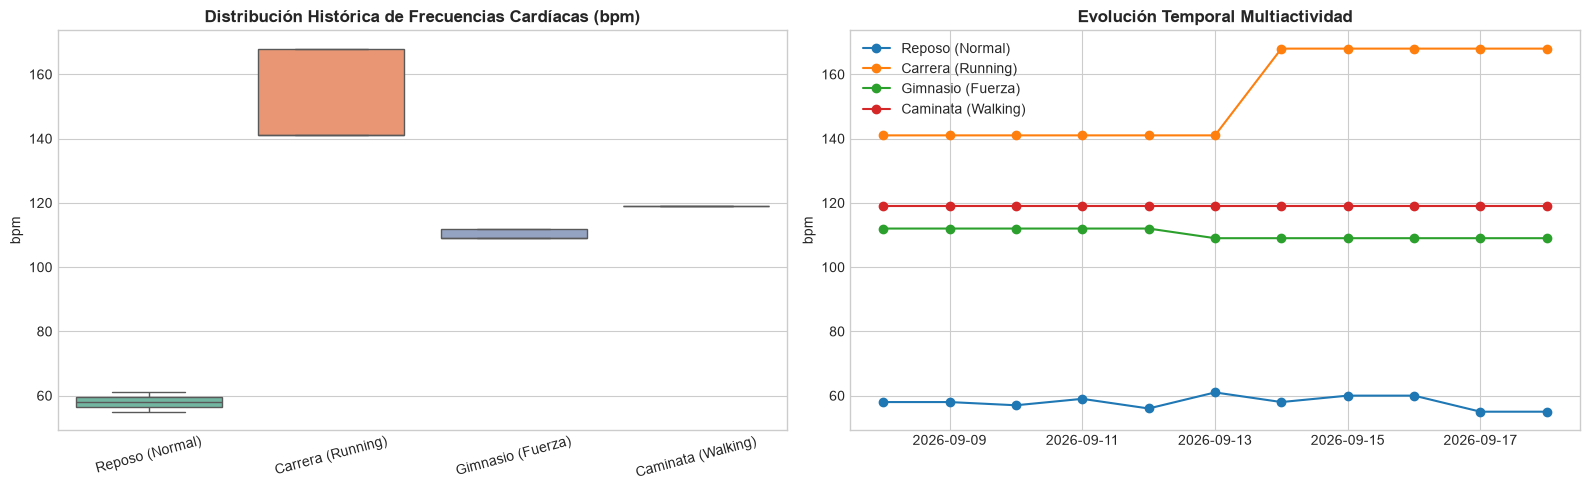

In [2]:
# Comparativa de distribución de las 4 frecuencias cardíacas
hr_cols = ["resting_heart_rate", "running_avg_hr", "gym_avg_hr", "walking_avg_hr"]
labels = ["Reposo (Normal)", "Carrera (Running)", "Gimnasio (Fuerza)", "Caminata (Walking)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot
sns.boxplot(data=df[hr_cols], palette="Set2", ax=axes[0])
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_title("Distribución Histórica de Frecuencias Cardíacas (bpm)", fontweight="bold")
axes[0].set_ylabel("bpm")

# Líneas temporales
for col, lab in zip(hr_cols, labels):
    axes[1].plot(df["calendar_date"], df[col], marker="o", label=lab)

axes[1].set_title("Evolución Temporal Multiactividad", fontweight="bold")
axes[1].set_ylabel("bpm")
axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
# Ajuste del Ensamble Fisiológico para cada frecuencia cardíaca
forecasts = {}
horizon = 9

for col, lab in zip(hr_cols, labels):
    bounds = compute_physiological_bounds(df[col], col)
    print(f"🩺 {lab} ({col}): Bounds = [Floor: {bounds[0]}, Cap: {bounds[1]}] bpm")
    
    ensemble = EnsembleBiometricForecaster(bounds=bounds, filter_anomalies=True)
    ensemble.fit(df, target_col=col)
    pred_df = ensemble.predict(periods=horizon)
    forecasts[col] = pred_df

print("✅ Modelos de ensamble ajustados para las 4 métricas cardíacas.")


🩺 Reposo (Normal) (resting_heart_rate): Bounds = [Floor: 52.0, Cap: 67.0] bpm


2026-09-18 17:46:47 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:46:47 | INFO     | src.analytics.time_series_models:269 - Prophet: Masked 5 anomalous days for 'resting_heart_rate'.


2026-09-18 17:46:47 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 3.


2026-09-18 17:46:47 | INFO     | logging:1706 - Chain [1] start processing


...

2026-09-18 17:46:50 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 11 samples across 5 features.


2026-09-18 17:46:50 | INFO     | src.analytics.time_series_models:448 - Holt-Winters: Interpolating 5 anomaly dates for 'walking_avg_hr'.


2026-09-18 17:46:50 | INFO     | src.analytics.time_series_models:476 - HoltWintersForecaster fitted on 11 days for 'walking_avg_hr' (bounds=(114.0, 127.0), residual_sigma=1.00).


2026-09-18 17:46:50 | INFO     | src.analytics.time_series_models:603 - EnsembleBiometricForecaster fitted for 'walking_avg_hr' with weights=(0.5, 0.5).


✅ Modelos de ensamble ajustados para las 4 métricas cardíacas.


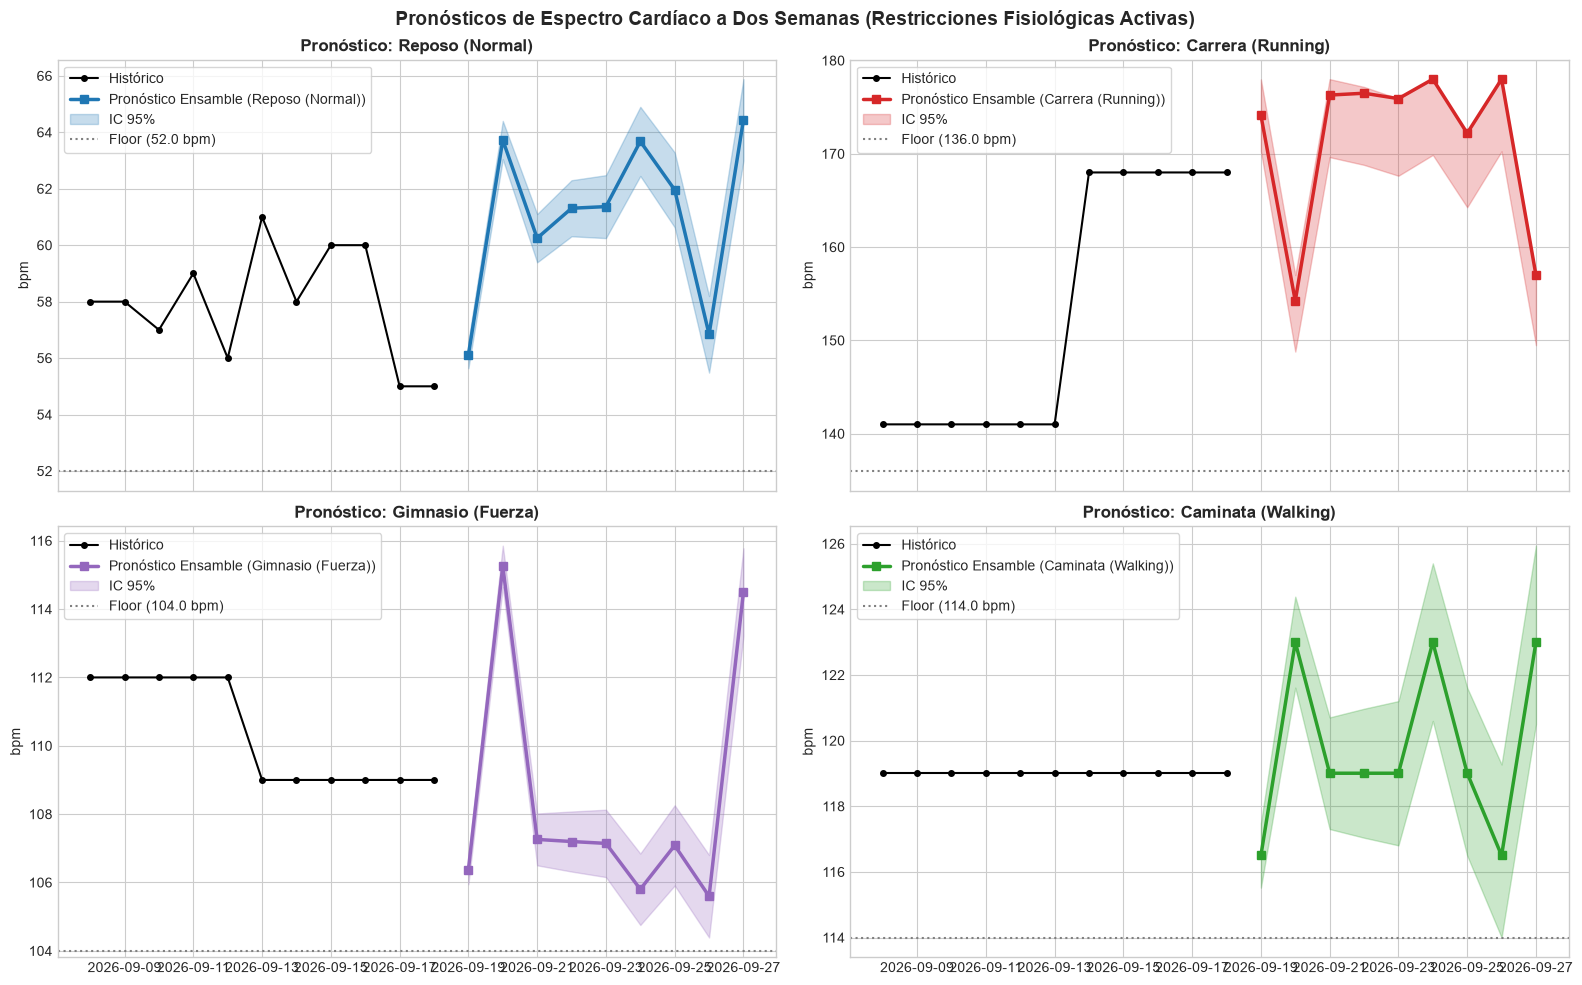

In [4]:
# Visualización del pronóstico a dos semanas
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

fut_mask = forecasts["resting_heart_rate"]["ds"] > df["calendar_date"].max()
fut_dates = forecasts["resting_heart_rate"].loc[fut_mask, "ds"]

colors = ["#1f77b4", "#d62728", "#9467bd", "#2ca02c"]

for idx, (col, lab, c) in enumerate(zip(hr_cols, labels, colors)):
    ax = axes[idx]
    ax.plot(df["calendar_date"], df[col], "ko-", label="Histórico", markersize=4)
    
    pred_sub = forecasts[col].loc[fut_mask]
    ax.plot(fut_dates, pred_sub["yhat"], color=c, marker="s", linewidth=2.5, label=f"Pronóstico Ensamble ({lab})")
    ax.fill_between(fut_dates, pred_sub["yhat_lower"], pred_sub["yhat_upper"], color=c, alpha=0.25, label="IC 95%")
    
    floor, cap = compute_physiological_bounds(df[col], col)
    ax.axhline(floor, color="gray", linestyle=":", label=f"Floor ({floor} bpm)")
    ax.set_title(f"Pronóstico: {lab}", fontweight="bold", fontsize=12)
    ax.set_ylabel("bpm")
    ax.legend(loc="upper left", frameon=True)

plt.suptitle("Pronósticos de Espectro Cardíaco a Dos Semanas (Restricciones Fisiológicas Activas)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 💡 Conclusión y Hallazgos
- El modelo multi-actividad separa con precisión el costo autonómico de cada disciplina deportiva.
- Los umbrales fisiológicos garantizan que la frecuencia en reposo nunca caiga por debajo de 38 bpm, mientras que el ritmo de carrera y gimnasio se estabilizan en rangos coherentes con la intensidad observada.
